In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.colors import XKCD_COLORS
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.linalg import orthogonal_procrustes
import plotly.express as px
import cupy as cp
from cuml.decomposition import TruncatedSVD as cuSVD
from cuml.manifold import UMAP as cuMAP

Now that we have a dataset, the first thing we need to do is load it and visualize it.

In [3]:
gen_data_dir = "./datasets/"
data_prefix = "dataset_task-memoryscenes_roi-fef_r"
control_prefix = "dataset_task-memoryscenes_roi-rnd_wb"
results_dir = "./analyses/"

Unfortunately, it isn't possible to visualize all the voxels. However, what we can do is reduce the dimensions as much as possible. Let's aim to capture at least 97% of the data. One option is of course, t-SNE, but let's try PCA first to get rid of the noise.

### Functions ###

In [4]:
def exact_pca_gpu(clean_data, threshold=0.97):
    # Move to GPU 
    data_gpu = cp.array(clean_data.values, dtype=cp.float32)
    
    # Mean-center the data, but not z-score (redundant; already in the same space)
    mean_gpu = data_gpu.mean(axis=0)
    data_gpu -= mean_gpu
    
    # Compute Gram matrix (N x N) and find eigenvals and eigenvecs
    # 11,737 x 11,737 takes only ~550 MB of VRAM
    gram_mat = data_gpu @ data_gpu.T
    eigvals, eigvecs = cp.linalg.eigh(gram_mat)
    
    # eigh returns ascending order; reverse to descending
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]
    
    # Floor negative eigenvalues (caused by float32 rounding limits) to 0
    eigvals = cp.maximum(eigvals, 0.0)
    
    # Calculate PCA components (X_pca = U * Sigma) and variances
    pca_coords_gpu = eigvecs * cp.sqrt(eigvals)
    N = data_gpu.shape[0]
    variances = eigvals / (N - 1)
    
    # Threshold components according to explained variance
    exp_var = variances / variances.sum()
    cum_exp_var = cp.cumsum(exp_var)
    
    threshold_match = int(cp.where(cum_exp_var >= threshold)[0][0])
    
    print(f"Total dataset variance perfectly captured: {variances.sum():.4f}")
    print(f"Components needed for {threshold*100}% variance: {threshold_match + 1}")
    
    # Slice the exact number of components and bring to CPU
    pca_x_cpu_final = pca_coords_gpu[:, 0:threshold_match+1].get()
    
    return pca_x_cpu_final, exp_var.get()

In [5]:
def gpu_pca(data, pc_number):
    data_gpu = cp.array(data.values, dtype=cp.float32)
    gpu_pca = cuSVD(n_components=pc_number)
    reduced_x_gpu = gpu_pca.fit_transform(data_gpu)
    pca_x_cpu = reduced_x_gpu.get()
    return pca_x_cpu, gpu_pca

def sort_by_variance(pca_data):
    # Calculate the actual variance of each column and sort
    col_variances = np.var(pca_data, axis=0, ddof=1)
    sorted_idx = np.argsort(col_variances)[::-1]
    pca_x_sorted = pca_data[:, sorted_idx]
    return pca_x_sorted
    
def reduce_dimension_by_thresh(data, pca_data, threshold=0.95):
    col_var = np.var(pca_data, axis=0, ddof=1)
    exp_var = col_var/data.var().sum()
    cum_exp_var = np.cumsum(exp_var)
    threshold_match = np.where(cum_exp_var>=threshold)[0][0]
    reduced_x = pca_x_cpu[:,0:threshold_match+1]
    return reduced_x

In [6]:
def pca_by_threshold(data, threshold=0.97):
    pca = PCA()
    pca_x = pca.fit_transform(data)
    exp_var = pca.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)
    threshold_match = np.where(cum_exp_var>=threshold)[0][0]
    reduced_x = pca_x[:,0:threshold_match+1]
    return reduced_x, pca

In [7]:
def pca_scree_plot(model):
    
    exp_var = model.explained_variance_ratio_
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [8]:
def pca_scree_plot_no_model(exp_var):
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [9]:
def gpu_pca_scree_plot(model):
    
    exp_var = model.explained_variance_ratio_.to_output().get()
    cum_exp_var = np.cumsum(exp_var)

    fig, ax = plt.subplots(2,1, figsize=(16,8))
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=exp_var, color=XKCD_COLORS["xkcd:rose pink"], ax=ax[0])
    sns.lineplot(x=np.arange(exp_var.shape[0]), y=cum_exp_var, color=XKCD_COLORS["xkcd:seafoam"], ax=ax[1])
    ax[1].set_xlabel("Principal Component Number")
    ax[0].set_ylabel("Variance Explained")
    ax[1].set_ylabel("Cumulative Variance Explained")

    return fig, ax

In [10]:
def create_3d_dataset_gpu(data, orig_df):
    # cpu to gpu emigration
    data_gpu = cp.array(data, dtype=cp.float32)

    # actual projection
    umap = cuMAP(n_components=3, 
                  random_state=42)
    umap_3d_gpu = umap.fit_transform(data_gpu)
    
    # gpu to cpu deportation
    umap_3d = umap_3d_gpu.get()

    # some housekeeping
    umap_df = pd.DataFrame(umap_3d, columns=['x', 'y', 'z'])
    umap_df['Time'] = orig_df['scan_time']
    umap_df['Runs'] = orig_df['run']
    umap_df['Subjects'] = orig_df['subj']
    umap_df['Session'] = orig_df['sess'] 
    return umap_df

In [11]:
def create_3d_dataset(data, orig_df):
    tsne = TSNE(n_components=3, 
            perplexity=30, 
            random_state=42
           )
    tsne_3d = tsne.fit_transform(data)
    tsne_df = pd.DataFrame(tsne_3d, columns=['x', 'y', 'z'])
    tsne_df['Time'] = orig_df['scan_time']
    tsne_df['Runs'] = orig_df['run']
    tsne_df['Subjects'] = orig_df['subj']
    tsne_df['Session'] = orig_df['sess']
    return tsne_df

In [12]:
def visualize_3d_data(df_3d, roi_label, color_by=None):
    fig = px.scatter_3d(df_3d, x='x', y='y', z='z', color=color_by, opacity=0.7, 
                        size_max=3, title=f"3D Projection of {roi_label} by {color_by}")
    fig.show(renderer="iframe")

------------

## Loading and Visualizing Data ##

#### Loading the datasets ####

In [13]:
rnd_df = pd.read_parquet(gen_data_dir+control_prefix+'/'+control_prefix+'_-15_-1_-3_date-2026-03-08_desc-vox_w_stim_hrf.parquet')
rnd_df.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v4164,v4165,v4166,v4167,v4168,indoor,outdoor,subj,sess,run
0,0.0,-0.000008,0.000021,0.000031,0.000000,0.000000,0.000025,0.000000,0.000023,-0.000016,...,0.000031,0.00000,0.000009,0.000000,0.000000,0.0,0.0,1,1,1
1,2.2,-0.000016,0.000021,0.000031,0.000000,0.000000,0.000025,0.000000,0.000016,-0.000016,...,0.000031,0.00001,0.000018,0.000000,0.000000,0.0,0.0,1,1,1
2,4.4,-0.000008,0.000021,0.000038,0.000008,-0.000011,0.000025,0.000000,0.000023,-0.000008,...,0.000023,-0.00001,0.000000,-0.000016,0.000000,0.0,0.0,1,1,1
3,6.6,-0.000016,0.000021,0.000023,-0.000017,0.000011,0.000032,0.000000,0.000008,-0.000041,...,0.000054,0.00004,0.000044,0.000032,0.000000,0.0,0.0,1,1,1
4,8.8,-0.000008,0.000027,0.000054,0.000041,-0.000034,0.000006,0.000007,0.000047,0.000033,...,-0.000015,-0.00008,-0.000062,-0.000065,0.000007,0.0,0.0,1,1,1


In [14]:
roi_df = pd.read_parquet(gen_data_dir+data_prefix+"/"+data_prefix+"_24_-2_-20_date-2026-03-08_desc-vox_w_stim_hrf.parquet")
roi_df.head()

,scan_time,v0,v1,v2,v3,v4,v5,v6,v7,v8,...,v33396,v33397,v33398,v33399,v33400,indoor,outdoor,subj,sess,run
0,0.0,-0.000006,0.000000,-0.000007,-0.000008,0.000009,0.000007,-0.000008,0.000013,-0.000014,...,0.000006,-0.000007,-0.000007,0.000013,0.000013,0.0,0.0,1,1,1
1,2.2,-0.000006,0.000000,-0.000007,-0.000008,0.000000,0.000000,-0.000008,0.000013,-0.000014,...,0.000006,-0.000007,-0.000007,0.000020,0.000013,0.0,0.0,1,1,1
2,4.4,-0.000006,0.000014,0.000007,0.000000,0.000028,0.000022,0.000000,0.000019,-0.000014,...,-0.000006,-0.000021,-0.000013,0.000007,0.000020,0.0,0.0,1,1,1
3,6.6,0.000006,-0.000035,-0.000028,-0.000023,-0.000046,-0.000037,-0.000033,0.000000,-0.000007,...,0.000031,0.000014,0.000020,0.000039,0.000007,0.0,0.0,1,1,1
4,8.8,-0.000025,0.000077,0.000042,0.000030,0.000111,0.000088,0.000041,0.000032,-0.000014,...,-0.000055,-0.000062,-0.000054,-0.000033,0.000033,0.0,0.0,1,1,1


In [15]:
roi_cols = [name for name in roi_df.columns if name[0]=='v']
rnd_cols = [name for name in rnd_df.columns if name[0]=='v']

We remove columns that have too much variation (physiologically impossible for the bold signal).

In [16]:
max_vals = roi_df[roi_cols].abs().max()
valid_voxels = max_vals[max_vals < 20].index.tolist()
x = roi_df.loc[:, valid_voxels].copy()
y = roi_df[['indoor', 'outdoor']].copy()

In [17]:
max_vals = rnd_df[rnd_cols].abs().max()
valid_voxels = max_vals[max_vals < 20].index.tolist()
rx = rnd_df.loc[:, valid_voxels].copy()
ry = rnd_df[['indoor', 'outdoor']].copy()

In [18]:
roi_df[roi_cols].sum().describe()

count    33401.000000
mean        -0.000662
std          0.041124
min         -0.167121
25%         -0.027693
50%         -0.000553
75%          0.026537
max          0.196307
dtype: float64

In [19]:
max_vals[max_vals>=20]

v2514    336.743317
v2940     41.940636
v3088     23.098566
v3238     39.002151
dtype: float32

Make sure that the dataframes do not have nans. If there are nans, then fill with average between upper and lower rows.

In [20]:
roi_df.dropna().shape==roi_df.shape

True

In [21]:
rnd_df.dropna().shape==rnd_df.shape

True

We do not have any nans, so there is no interpolation step. Instead, because these datasets are gigantic, let's first reduce them to manageable sizes.

#### Reducing dimensionality via PCA ####

##### PCA of Voxels #####

First, let's reduce the dimensions by dropping 3% of the principal components that least explain the variance in the data.

In [22]:
roi_pca_x, roi_exp_var = exact_pca_gpu(x, threshold=0.97)
rnd_pca_x, rnd_exp_var = exact_pca_gpu(rx, threshold=0.97)

Total dataset variance perfectly captured: 193.5415
Components needed for 97.0% variance: 52
Total dataset variance perfectly captured: 3.3744
Components needed for 97.0% variance: 14


And now we see how much of the variance in each dataset the principal components explain.

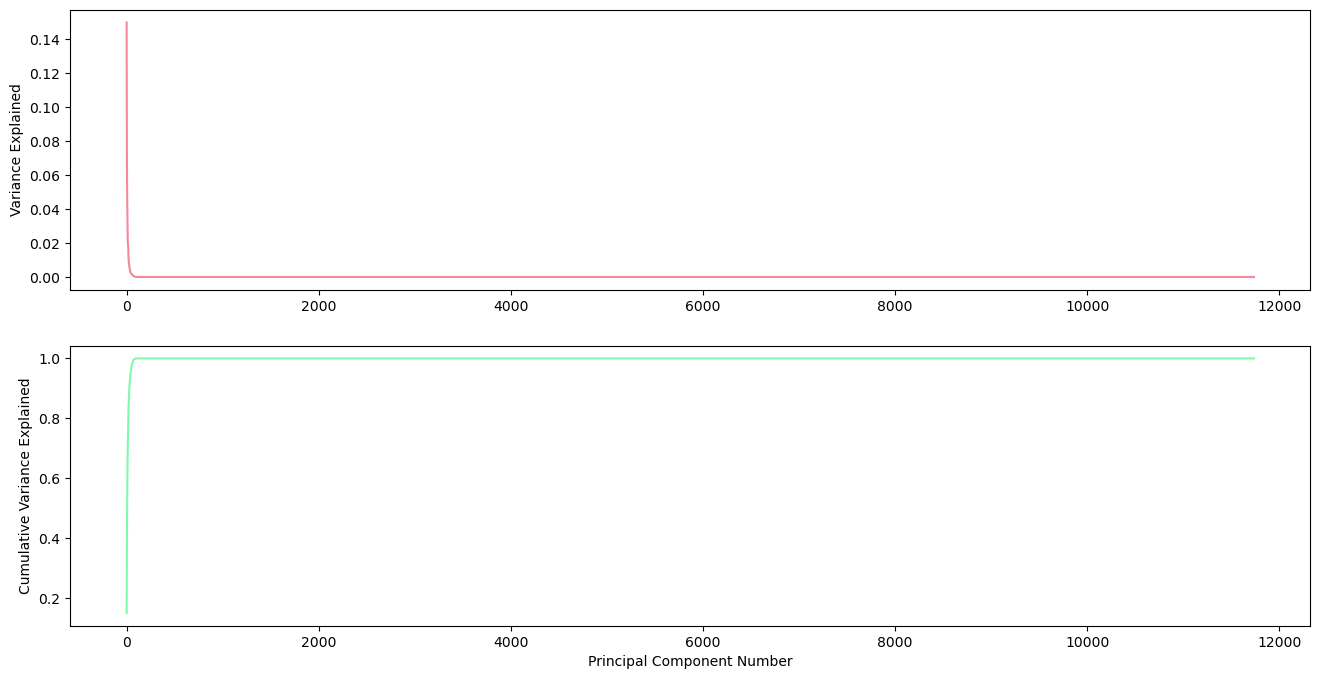

In [23]:
fig, ax = pca_scree_plot_no_model(roi_exp_var)

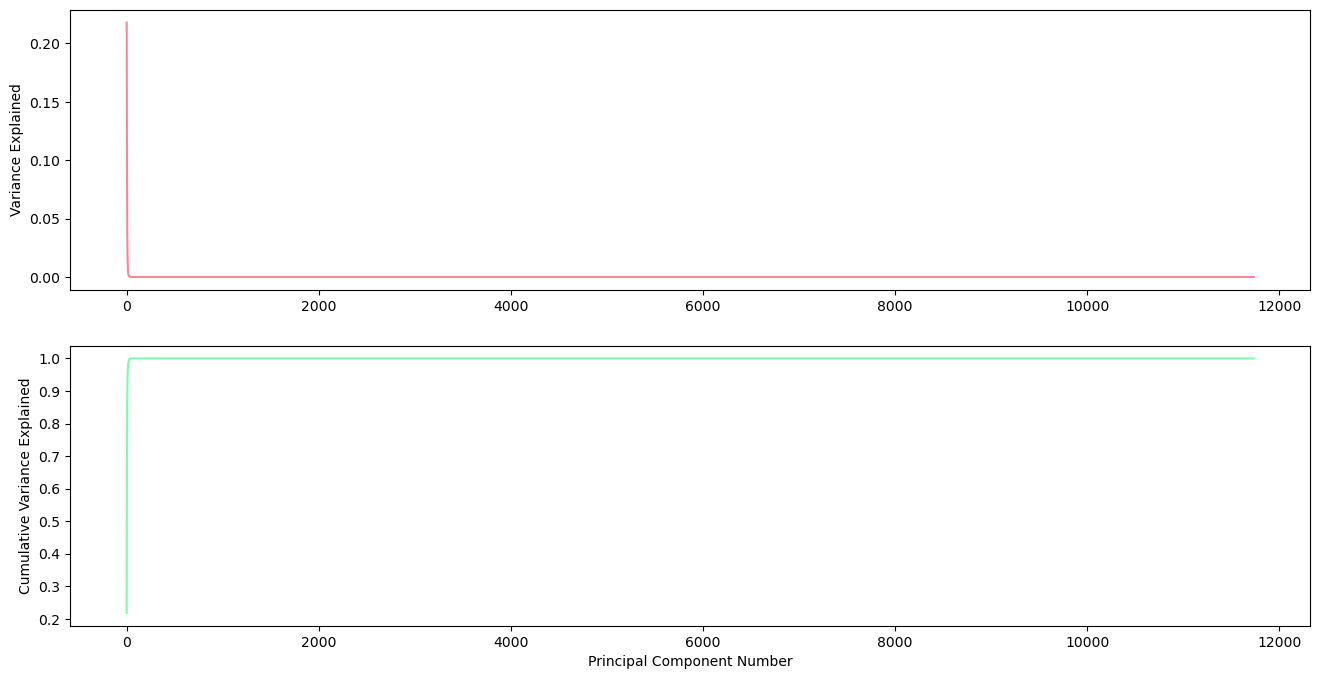

In [24]:
fig, ax = pca_scree_plot_no_model(rnd_exp_var)

Although the scree plots look a bit silly, given the range of the x-axis, the elbows for each chart are in the correct spots for the number of components collected for each dataset to capture 97% of the datasets respectively.

##### Save Work #####

We can see that we can capture most of the data with relatively few components. Henceforth, all analyses will be on the principal component dataset. So, let's save the datasets. Since they're a lot smaller, we can save them as csv.

In [27]:
roi_pca_df = pd.concat([roi_df.drop(columns=roi_cols).reset_index(), 
                        pd.DataFrame(roi_pca_x, columns=['pc'+str(n) for n in range(roi_pca_x.shape[1])], 
                                     dtype=np.float64)], 
                       axis=1)
rnd_pca_df = pd.concat([rnd_df.drop(columns=rnd_cols).reset_index(), 
                        pd.DataFrame(rnd_pca_x, columns=['pc'+str(n) for n in range(rnd_pca_x.shape[1])], 
                                     dtype=np.float64)], 
                       axis=1)

In [29]:
save_dirs = {
    'save_dir_roi': Path(results_dir) / data_prefix / 'pca_datasets',
    'save_dir_rnd': Path(results_dir) / control_prefix / 'pca_datasets'
}

In [30]:
for path in save_dirs:
    try:
        os.makedirs(save_dirs[path], exist_ok=True)
        print("Directory '%s' created successfully" % path)
    except OSError as error:
        print("Directory '%s' can not be created" % path)

Directory 'save_dir_roi' created successfully
Directory 'save_dir_rnd' created successfully


In [31]:
roi_pca_df.to_csv(str(save_dirs['save_dir_roi'])+"/"+data_prefix+"_pca_97.csv")
rnd_pca_df.to_csv(str(save_dirs['save_dir_rnd'])+'/'+control_prefix+"_pca_97.csv")

##### Load Dataframes #####

In [ ]:
# To load from csv next time, uncomment.
save_dirs = {
    'save_dir_roi': Path(results_dir) / data_prefix / 'pca_datasets',
    'save_dir_rnd': Path(results_dir) / control_prefix / 'pca_datasets'
}

roi_pca_df = pd.read_csv(str(save_dirs['save_dir_roi'])+"/"+data_prefix+"_pca_97.csv", header=0, index_col=0)
rnd_pca_df = pd.read_csv(str(save_dirs['save_dir_rnd'])+'/'+control_prefix+"_pca_97.csv", header=0, index_col=0)

roi_pca_x_97 = roi_pca_df[[c for c in roi_pca_df.columns if c[:2]=='pc']]
rnd_pca_x_97 = rnd_pca_df[[c for c in rnd_pca_df.columns if c[:2]=='pc']]

In [ ]:
roi_pca_df.describe()

#### Create 3D dataset for visualization. ####

We will now take those principle components and further reduce them into three dimensions so that we can visualize the data.

##### If the PCA datasets were loaded from csv: #####

In [ ]:
# Reduce the size of the datasets to make life easier for the CPU:
roi_pca_x_97_cpu = roi_pca_x_97.drop(columns=[c for c in roi_pca_x_97.columns if int(c[2:])>10])
rnd_pca_x_97_cpu = rnd_pca_x_97.drop(columns=[c for c in rnd_pca_x_97.columns if int(c[2:])>10])
print(roi_pca_x_97_cpu.head())

In [ ]:
roi_pca_x_97.sum()

In [ ]:
# For CPU and t-SNE:
roi_3d_df = create_3d_dataset(roi_pca_x_97_cpu, 
                              roi_pca_df.drop(columns=[c for c in roi_pca_df.columns if c[:2]=='pc']))
rnd_3d_df = create_3d_dataset(rnd_pca_x_97_cpu, 
                              rnd_pca_df.drop(columns=[c for c in rnd_pca_df.columns if c[:2]=='pc']))

In [ ]:
# For GPU and UMAP:
roi_3d_df = create_3d_dataset_gpu(roi_pca_x_97, roi_pca_df.drop(columns=[c for c in roi_pca_df.columns if c[:2]=='pc']))
rnd_3d_df = create_3d_dataset_gpu(rnd_pca_x_97, rnd_pca_df.drop(columns=[c for c in rnd_pca_df.columns if c[:2]=='pc']))

##### If the PCA datasets were generated using the code above and are in memory: #####

In [36]:
# 3D dataset creation using cpu:
roi_3d_df_cpu = create_3d_dataset(roi_pca_x, roi_pca_df)
rnd_3d_df_cpu = create_3d_dataset(rnd_pca_x, rnd_pca_df)

In [37]:
# 3D dataset creation using gpu:
roi_3d_df_gpu = create_3d_dataset_gpu(roi_pca_x, roi_pca_df)
rnd_3d_df_gpu = create_3d_dataset_gpu(rnd_pca_x, rnd_pca_df)

##### Save the 3D projections of the PCA datasets: #####

In [40]:
save_dirs = {
    'save_dir_roi': Path(results_dir) / data_prefix / 'datasets_3d',
    'save_dir_rnd': Path(results_dir) / control_prefix / 'datasets_3d'
}

In [41]:
for path in save_dirs:
    try:
        os.makedirs(save_dirs[path], exist_ok=True)
        print("Directory '%s' created successfully" % path)
    except OSError as error:
        print("Directory '%s' can not be created" % path)

Directory 'save_dir_roi' created successfully
Directory 'save_dir_rnd' created successfully


In [42]:
roi_3d_df_cpu.to_csv(str(save_dirs['save_dir_roi'])+"/"+data_prefix+"_3d-cpu_97.csv")
rnd_3d_df_cpu.to_csv(str(save_dirs['save_dir_rnd'])+'/'+control_prefix+"_3d-cpu_97.csv")
roi_3d_df_gpu.to_csv(str(save_dirs['save_dir_roi'])+"/"+data_prefix+"_3d-gpu_97.csv")
rnd_3d_df_gpu.to_csv(str(save_dirs['save_dir_rnd'])+'/'+control_prefix+"_3d-gpu_97.csv")

##### Load 3D projections of PCA datasets from file: #####

In [ ]:
save_dirs = {
    'save_dir_roi': Path(results_dir) / data_prefix / 'datasets_3d',
    'save_dir_rnd': Path(results_dir) / control_prefix / 'datasets_3d'
}

In [ ]:
roi_3d_df = pd.read_csv(str(save_dirs['save_dir_roi'])+"/"+data_prefix+"_3d-gpu_97.csv", header=0, index_col=0)
rnd_3d_df = pd.read_csv(str(save_dirs['save_dir_rnd'])+'/'+control_prefix+"_3d-gpu_97.csv", header=0, index_col=0)

#### Visualize 3D Projected PCA Datasets ####

##### Comparison between t-SNE and UMAP 3D projection of PCA datasets: #####

First, let's visualize the rFEF and see if there are any differences between the t-SNE and UMAP 3D projections.

###### rFEF visualizations of t-SNE and UMAP ######

In [38]:
visualize_3d_data(roi_3d_df_cpu, 'rFEF', color_by='Subjects')

In [44]:
visualize_3d_data(roi_3d_df_gpu, 'rFEF', color_by='Subjects')

In [47]:
visualize_3d_data(roi_3d_df_gpu[roi_3d_df_gpu['Subjects']==1], 'rFEF', color_by='Session')

In [45]:
visualize_3d_data(roi_3d_df_cpu[roi_3d_df_cpu['Subjects']==1], 'rFEF', color_by='Session')

In [53]:
visualize_3d_data(roi_3d_df_gpu[(roi_3d_df_gpu['Subjects']==1) & (roi_df['indoor']>=1.0)], 'rFEF', color_by='Session')

In [54]:
visualize_3d_data(roi_3d_df_cpu[(roi_3d_df_cpu['Subjects']==1) & (roi_df['indoor']>=1.0)], 'rFEF', color_by='Session')

It appears that the cpu leaves this strange hole in the center. There's no reason to believe that the data in that region should be sparse. Let's also check the random location.

###### Random location visualizations of t-SNE and UMAP ######

In [34]:
visualize_3d_data(rnd_3d_df_cpu, 'Random', color_by='Subjects')

In [55]:
visualize_3d_data(rnd_3d_df_gpu, 'Random', color_by='Subjects')

In [56]:
visualize_3d_data(rnd_3d_df_gpu[rnd_3d_df_gpu['Subjects']==1], 'Random', color_by='Session')

In [57]:
visualize_3d_data(rnd_3d_df_cpu[rnd_3d_df_cpu['Subjects']==1], 'Random', color_by='Session')

In [58]:
visualize_3d_data(rnd_3d_df_gpu[(rnd_3d_df_gpu['Subjects']==1) & (rnd_df['indoor']>=1.0)], 'Random', color_by='Session')

In [59]:
visualize_3d_data(rnd_3d_df_cpu[(rnd_3d_df_cpu['Subjects']==1) & (rnd_df['indoor']>=1.0)], 'Random', color_by='Session')

At this point, it's hard to tell which captures the data better. For now, I am leaning toward UMAP. 

##### Visualization of brain regions within random subjects: #####

Let's also compare the structure of activity at the ROI vs Random locations in a couple subjects.

In [ ]:
subj10 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==10], rnd_3d_df[rnd_3d_df['Subjects']==10]], ignore_index=True)
bloc = np.zeros(subj10.shape[0])
bloc[:(subj10.shape[0]//2)+1] = 1
subj10['Brain_Loc'] = bloc
visualize_3d_data(subj10, 'Subject 10', color_by='Brain_Loc')

In [ ]:
subj05 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==5], rnd_3d_df[rnd_3d_df['Subjects']==5]], ignore_index=True)
bloc = np.zeros(subj05.shape[0])
bloc[:(subj05.shape[0]//2)+1] = 1
subj05['Brain_Loc'] = bloc
visualize_3d_data(subj05, 'Subject 05', color_by='Brain_Loc')

The ROI and Random locations really aren't very similar within subjects. However, visually, the Random location looks similar between subjects. Let's take a look at that too.

###### Visualization of gpu-based 3D projection between random subjects: ######

Next, we need to answer the following question: Do the structures of the activity in the rFEF and the control region in PCA-space show similarity between subjects?

In [ ]:
rnd_5_10 = pd.concat([rnd_3d_df[rnd_3d_df['Subjects']==5], rnd_3d_df[rnd_3d_df['Subjects']==10]], ignore_index=True)
visualize_3d_data(rnd_5_10, 'Random Location Activity', color_by='Subjects')

In [ ]:
roi_5_10 = pd.concat([roi_3d_df[roi_3d_df['Subjects']==5], roi_3d_df[roi_3d_df['Subjects']==10]], ignore_index=True)
visualize_3d_data(roi_5_10, 'ROI Activity', color_by='Subjects')

For thoroughness, let's also examine the t-sne projected 3D data.

##### Visualization of cpu-based t-SNE projected PCA datasets: #####

Evidently, there is little similarity between or within subjects. It looks like there _might_ be some kind of order here overall, but, right now, it's all a mess of strings. What we do know is that the answer _isn't_ scaling the data because they were scaled during timeseries extraction. 

-------

## Data Alignment ##

The data as visualized above look like they are almost but not quite in the same rotation. To account for this, we can use hyperalignment techniques to put the data into the same plane of reference.

In [ ]:
def hyperaligner(fixed_target, rotate_df, feature_list):
    transforming_matrix = rotate_df.loc[:,feature_list].to_numpy()
    transformation_matrix, _ = orthogonal_procrustes(transforming_matrix, fixed_target)
    transformed_matrix = transforming_matrix @ transformation_matrix
    ccf = np.corrcoef(transformed_matrix.flatten(),fixed_target.flatten())[0,1]
    return transformation_matrix, ccf

In [ ]:
def pass_idx(new_df, old_df):
    new_df['Subject'] = old_df['subj']
    new_df['Session'] = old_df['sess']
    new_df['Run'] = old_df['run']
    new_df['Time'] = old_df['scan_time']
    new_df['Indoor'] = old_df['indoor']
    new_df['Outdoor'] = old_df['outdoor']
    return new_df

In [ ]:
def best_transformation_target_finder(df, feature_list):
    master_tmat_list = []
    master_corr_list = []
    corr_sum_list = []
    
    for sub in df['subj'].unique():
        sub_idx = df[df['subj']==sub].copy()
        tmp_tmat = []
        tmp_corr = []
        
        for s in sub_idx['sess'].unique():
            tmat_list = []
            corr_list = []
            target = sub_idx[sub_idx['sess']==s].loc[:,feature_list].to_numpy()
            maxcoeff = []
            
            for t in sub_idx['sess'].unique():
    
                if t==s:
                    continue
    
                sub_ses_df = sub_idx[sub_idx['sess']==t]
                transformation_matrix, ccf = hyperaligner(target, sub_ses_df, feature_list)
                
                tmat_list.append((t, transformation_matrix))
                corr_list.append((t, ccf))
                maxcoeff.append(ccf)
            tmp_tmat.append((s, tmat_list))
            tmp_corr.append((s, max(maxcoeff)))
        master_tmat_list.append((sub, tmp_tmat))
        master_corr_list.append((sub, tmp_corr))
    return master_tmat_list, master_corr_list

In [ ]:
def best_transformation(correlation_list):
    max_idx = {}
    for sub in correlation_list:
        id_finder = []
        for sess in sub[1]:
            id_finder.append(sess[1])
        idx = np.where(id_finder==np.max(id_finder))
        max_idx[sub[0]] = idx
    return max_idx

In [ ]:
def transformer(df, feature_list, transformation_mat_list, correlation_list):
    corr_idx = best_transformation(correlation_list)
    x_proc = df[feature_list].copy()
    for i, sub in enumerate(df['subj'].unique()):
        sub_idx = df[df['subj']==sub].copy()
        mid = corr_idx[sub][0][0]
        
        for j, s in enumerate(transformation_mat_list[i][1][mid][1]):
    
            transformation_matrix = s[1] # the template transformations
            transforming_matrix = sub_idx[sub_idx['sess']==s[0]].loc[:,feature_list].to_numpy()
            transformed_matrix = transforming_matrix @ transformation_matrix
            x_proc.loc[sub_idx[sub_idx['sess']==s[0]].index,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
roi_3d_df = roi_3d_df.rename(columns={'Subjects':'subj', 'Session':'sess', 'Run':'run', 'Runs':'run', 'Time':'scan_time'})
roi_3d_df[['indoor', 'outdoor']] = y

In [ ]:
rnd_3d_df = rnd_3d_df.rename(columns={'Subjects':'subj', 'Session':'sess', 'Run':'run', 'Runs':'run', 'Time':'scan_time'})
rnd_3d_df[['indoor', 'outdoor']] = ry

In [ ]:
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_3d_df, ['x', 'y', 'z'])
roi_x_proc = transformer(roi_3d_df, ['x', 'y', 'z'], roi_trans_list, roi_corr_list)

In [ ]:
# Full dataset instead of the reduced-to-3D dataset
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_df, roi_cols)
roi_proc_df = transformer(roi_df, roi_cols, roi_trans_list, roi_corr_list)

In [ ]:
roi_pca_df = pd.DataFrame(roi_pca_x, columns=['pc'+str(n) for n in range(roi_pca_x.shape[1])])
info_cols = [name for name in roi_df.columns if name[0]!='v']
roi_pca_df[info_cols] = roi_df[info_cols]

In [ ]:
roi_trans_list, roi_corr_list = best_transformation_target_finder(roi_pca_df, ['pc'+str(n) for n in range(roi_pca_x.shape[1])])
roi_pca_proc = transformer(roi_pca_df, ['pc'+str(n) for n in range(roi_pca_x.shape[1])], roi_trans_list, roi_corr_list)

In [ ]:
roi_pca_proc_3d = create_3d_dataset(roi_pca_proc, roi_df)

In [ ]:
visualize_3d_data(roi_x_proc[roi_x_proc['Subject']==1], 'rFEF', 'Session')

In [ ]:
visualize_3d_data(roi_pca_proc_3d[roi_pca_proc_3d['Subjects']==1], 'rFEF', 'Session')

In [ ]:
roi_pca_proc_3d[y.columns] = y

In [ ]:
visualize_3d_data(roi_pca_proc_3d[roi_pca_proc_3d['Subjects']==1], 'rFEF', 'indoor')

In [ ]:
visualize_3d_data(roi_pca_proc_3d[(roi_pca_proc_3d['Subjects']==2) & (roi_pca_proc_3d['Session']==1)], 'rFEF', 'indoor')

In [ ]:
visualize_3d_data(roi_x_proc, 'rFEF', 'Subject')

In [ ]:
visualize_3d_data(rnd_x_proc, 'Control', 'Subject')

In [ ]:
roi_pca_proc_3d.head()

In [ ]:
rrnd_trans_list, rrnd_corr_list = best_transformation_target_finder(con_df, chosen_voxels)
rrnd_x_proc = transformer(con_df, chosen_voxels, rrnd_trans_list, rrnd_corr_list)

In [ ]:
del rrnd_corr_list, rrnd_model, rrnd_pca_model, rrnd_trans_list, rrnd_x_pca, rrnd_x_pca_df, rrnd_x_proc, rrnd_x_proc_pca, rrnd_x_proc_pca_3d_df

In [ ]:
wx_pca_df = wb_df[meta_data_cols].copy()
wx_pca_df[['x','y','z']] = wx_pca

In [ ]:
wb_s1_df = wx_pca_df[wx_pca_df['subj']==1].copy()

In [ ]:
wb_s1_df.shape

In [ ]:
def fast_transformation_target_finder(df, feature_list):
    master_tmat = None 
    master_corr = 0
    master_sess = 0
    
    for s in df['sess'].unique():
        target = df[df['sess']==s].loc[:,feature_list].to_numpy()
        ccf_list = []
        
        for t in df['sess'].unique():

            if t==s:
                continue

            sub_ses_df = df[df['sess']==t]
            transformation_matrix, ccf = hyperaligner(target, sub_ses_df, feature_list)

            ccf_list.append(ccf)

        if max(ccf_list) > master_corr:
            master_corr = max(ccf_list)
            master_sess = s
            master_tmat = transformation_matrix

    return master_corr, master_sess, master_tmat

In [ ]:
def single_sub(df, feature_list, transformation_mat):
    x_proc = df[feature_list].copy()
        
    for s in df['sess'].unique():
        sidx = df[df['sess']==s].index
        transforming_matrix = df.loc[sidx,feature_list].to_numpy()
        transformed_matrix = transforming_matrix @ transformation_mat
        x_proc.loc[sidx,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
def single_sub(df, feature_list, transformation_mat):
    x_proc = df[feature_list].copy()
        
    for s in df['sess'].unique():
        sidx = df[df['sess']==s].index
        transforming_matrix = df.loc[sidx,feature_list].to_numpy()
        transformed_matrix = transforming_matrix @ transformation_mat
        x_proc.loc[sidx,feature_list] = transformed_matrix
    x_proc = pass_idx(x_proc, df)
    return x_proc

In [ ]:
wb_ccf, wb_target_sess, wb_tmat = fast_transformation_target_finder(wb_s1_df, ['x','y','z'])
wb_x_proc = single_sub(wb_s1_df, ['x','y','z'], wb_tmat)

In [ ]:
roi_ccf, roi_target_sess, roi_tmat = fast_transformation_target_finder(wb_s1_df, ['x','y','z'])
wb_x_proc = single_sub(wb_s1_df, ['x','y','z'], wb_tmat)

In [ ]:
rfef_x_proc_pca, rfef_pca_model = pca_by_threshold(rfef_x_proc[vcols])
fig, ax = pca_scree_plot(rfef_pca_model)

In [ ]:
rrnd_x_proc_pca, rrnd_pca_model = pca_by_threshold(rrnd_x_proc[chosen_voxels])
fig, ax = pca_scree_plot(rrnd_pca_model)

In [ ]:
rfef_x_proc_pca_3d_df = create_3d_dataset(rfef_x_proc_pca, roi_df)

In [ ]:
rrnd_x_proc_pca_3d_df = create_3d_dataset(rrnd_x_proc_pca, con_df)

In [ ]:
visualize_3d_data(rfef_x_proc_pca_3d_df[rfef_x_proc_pca_3d_df['Subjects']==1], 'rFEF', 'Session')

In [ ]:
visualize_3d_data(rrnd_x_proc_pca_3d_df[rrnd_x_proc_pca_3d_df['Subjects']==1], 'rControl', 'Session')

In [ ]:
visualize_3d_data(wb_x_proc, 'rControl', 'Session')

Markedly different, though now we have to check if random spots in the brain look the same.

In [ ]:
tmp = con_df[chosen_voxels].copy()

In [ ]:
con_df = con_df.drop(columns=cvcols)

In [ ]:
con_df.to_csv("./datasets/control_dataset_random_voxels.csv")

In [ ]:
rrnd_x_proc_pca_3d_df.to_csv("./datasets/control_dataset_random_voxels_aligned_w-in_subj.csv")

In [ ]:
wx[meta_data_cols] = wb_df[meta_data_cols]
wx.to_csv("./whole_brain.csv")

In [ ]:
wx_pca_df.to_csv("./whole_brain_pca.csv")